Loading pre-processed train and test data...
Train size: X=(56000, 50), y=(56000,)
Test size: X=(14000, 50), y=(14000,)

2. Applying SMOTE to Handle Class Imbalance...
Original Train Target Distribution:
Churn
0    32623
1    23377
Name: count, dtype: int64
SMOTE Train Target Distribution:
Churn
0    32623
1    32623
Name: count, dtype: int64

3. Training Random Forest with RandomizedSearchCV...
Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}

4. Training Gradient Boosting with RandomizedSearchCV...
Best GB Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}

--- Advanced Models Performance ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Random Forest,0.6023,0.5216,0.5700,0.5447,0.6322
Gradient Boosting,0.6054,0.5279,0.5156,0.5217,0.6330


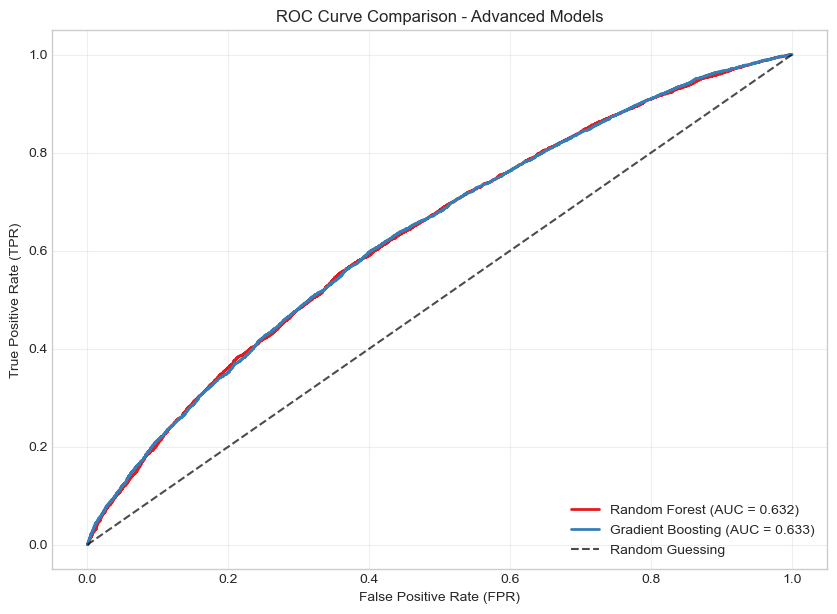


Best Model based on $ROC AUC$: Gradient Boosting
Best model successfully saved to: ../models/best_churn_model.pkl


In [ ]:
# ==============================================================================
# NOTEBOOK 10: Advanced Models (Random Forest, Gradient Boosting)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set1")

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/results', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. Load Pre-split Data (From Notebook 08)
# ═══════════════════════════════════════════════════════════════════════════════
print("Loading pre-processed train and test data...")

# لود کردن فایل‌های جداگانه که در نوت‌بوک ۰۸ اسکیل و انتخاب ویژگی شده‌اند
train_df = pd.read_csv('../data/processed/train_data_final.csv')
test_df = pd.read_csv('../data/processed/test_data_final.csv')

X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']

X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']

print(f"Train size: X={X_train.shape}, y={y_train.shape}")
print(f"Test size: X={X_test.shape}, y={y_test.shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 2. Handling Class Imbalance
# ═══════════════════════════════════════════════════════════════════════════════
print("\n2. Applying SMOTE to Handle Class Imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original Train Target Distribution:\n{y_train.value_counts()}")
print(f"SMOTE Train Target Distribution:\n{y_train_smote.value_counts()}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. Helper Functions for Evaluation
# ═══════════════════════════════════════════════════════════════════════════════
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }
    return metrics, y_prob

results_list = []
prob_dict = {}

# ═══════════════════════════════════════════════════════════════════════════════
# 4. First Model: Random Forest (with Tuning and class_weight)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n3. Training Random Forest with RandomizedSearchCV...")
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=rf, param_distributions=rf_params, n_iter=3, 
    cv=2, scoring='roc_auc', random_state=42, n_jobs=-1
)
rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

metrics_rf, prob_rf = evaluate_model(best_rf, X_test, y_test, 'Random Forest')
results_list.append(metrics_rf)
prob_dict['Random Forest'] = prob_rf
print(f"Best RF Params: {rf_random.best_params_}")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Second Model: Gradient Boosting (with Tuning on SMOTE Data)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n4. Training Gradient Boosting with RandomizedSearchCV...")
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_random = RandomizedSearchCV(
    estimator=gb, param_distributions=gb_params, n_iter=3, 
    cv=2, scoring='roc_auc', random_state=42, n_jobs=-1
)
gb_random.fit(X_train_smote, y_train_smote)
best_gb = gb_random.best_estimator_

metrics_gb, prob_gb = evaluate_model(best_gb, X_test, y_test, 'Gradient Boosting')
results_list.append(metrics_gb)
prob_dict['Gradient Boosting'] = prob_gb
print(f"Best GB Params: {gb_random.best_params_}")


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Model Evaluation and Comparison
# ═══════════════════════════════════════════════════════════════════════════════
print("\n--- Advanced Models Performance ---")
results_df = pd.DataFrame(results_list).set_index('Model')
display(results_df.round(4))

plt.figure(figsize=(10, 7))
for model_name, prob in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = results_df.loc[model_name, 'ROC AUC']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing', alpha=0.7)
plt.title('ROC Curve Comparison - Advanced Models')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('../data/results/10_advanced_roc_curves.png', dpi=300)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. Selecting and Saving the Best Model
# ═══════════════════════════════════════════════════════════════════════════════
best_model_name = results_df['ROC AUC'].idxmax()
print(f"\nBest Model based on $ROC AUC$: {best_model_name}")

model_mapping = {
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb
}

final_best_model = model_mapping[best_model_name]

model_path = '../models/best_churn_model.pkl'
joblib.dump(final_best_model, model_path)
print(f"Best model successfully saved to: {model_path}")
